<a href="https://colab.research.google.com/github/chithushik/visual_search_recommendation.ipynb/blob/main/visual_search_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [2]:
import os

# Set your Kaggle API token directly
os.environ["KAGGLE_API_TOKEN"] = "KGAT_1b22689d20139293990267c88075e517"

# Download the fashion dataset
!kaggle datasets download -d paramaggarwal/fashion-product-images-small

# Unzip the downloaded dataset
!unzip -q fashion-product-images-small.zip -d fashion_data

print("Dataset successfully downloaded and unzipped!")

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:03<00:00, 149MB/s]

Dataset successfully downloaded and unzipped!


--- Product Data Preview ---
      id gender masterCategory subCategory  articleType  \
0  15970    Men        Apparel     Topwear       Shirts   
1  39386    Men        Apparel  Bottomwear        Jeans   
2  59263  Women    Accessories     Watches      Watches   
3  21379    Men        Apparel  Bottomwear  Track Pants   
4  53759    Men        Apparel     Topwear      Tshirts   

                              productDisplayName  
0               Turtle Check Men Navy Blue Shirt  
1             Peter England Men Party Blue Jeans  
2                       Titan Women Silver Watch  
3  Manchester United Men Solid Black Track Pants  
4                          Puma Men Grey T-shirt  


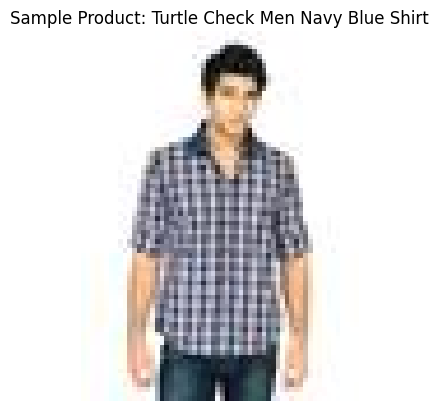

In [3]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load the metadata file that describes each item
df = pd.read_csv("fashion_data/styles.csv", on_bad_lines='skip')

# Display the first 5 rows of product information
print("--- Product Data Preview ---")
print(df[['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'productDisplayName']].head())

# 2. Display the first product image
sample_id = df.iloc[0]['id']
img_path = f"fashion_data/images/{sample_id}.jpg"

img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Sample Product: {df.iloc[0]['productDisplayName']}")
plt.axis('off')
plt.show()

In [4]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm
import numpy as np

# 1. Load pre-trained ResNet50 model
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# Remove the last classification layer so we get raw features (embeddings)
model = torch.nn.Sequential(*list(model.children())[:-1])
model = model.cuda()
model.eval()

# 2. Define image preparation steps (resize, convert to tensor, normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 3. Extract features for first 1,000 items
features_list = []
valid_ids = []

# Process first 1000 items
subset_df = df.head(1000)

with torch.no_grad():
    for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
        img_id = row['id']
        img_path = f"fashion_data/images/{img_id}.jpg"

        try:
            img = Image.open(img_path).convert('RGB')
            tensor_img = transform(img).unsqueeze(0).cuda()

            # Extract features
            embedding = model(tensor_img).squeeze().cpu().numpy()

            features_list.append(embedding)
            valid_ids.append(img_id)
        except Exception as e:
            # Skip if image missing or broken
            continue

# Save as numpy array
embeddings = np.array(features_list)
print("\nFeature Extraction Complete!")
print(f"Total processed images: {len(embeddings)}")
print(f"Embedding shape for each image: {embeddings[0].shape}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]
100%|██████████| 1000/1000 [00:09<00:00, 102.41it/s]


Feature Extraction Complete!
Total processed images: 1000
Embedding shape for each image: (2048,)


In [5]:
# 1. Install FAISS library
!pip install faiss-cpu -q

import faiss

# 2. Convert embeddings to float32 (required by FAISS)
embeddings_faiss = embeddings.astype('float32')

# 3. Create FAISS index using L2 distance (Euclidean distance)
dimension = embeddings_faiss.shape[1]  # 2048 dimensions
index = faiss.IndexFlatL2(dimension)

# 4. Add all image embeddings into the index
index.add(embeddings_faiss)

print(f"FAISS Index Created Successfully!")
print(f"Total items stored in index: {index.ntotal}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 100.0 MB/s eta 0:00:00
FAISS Index Created Successfully!
Total items stored in index: 1000


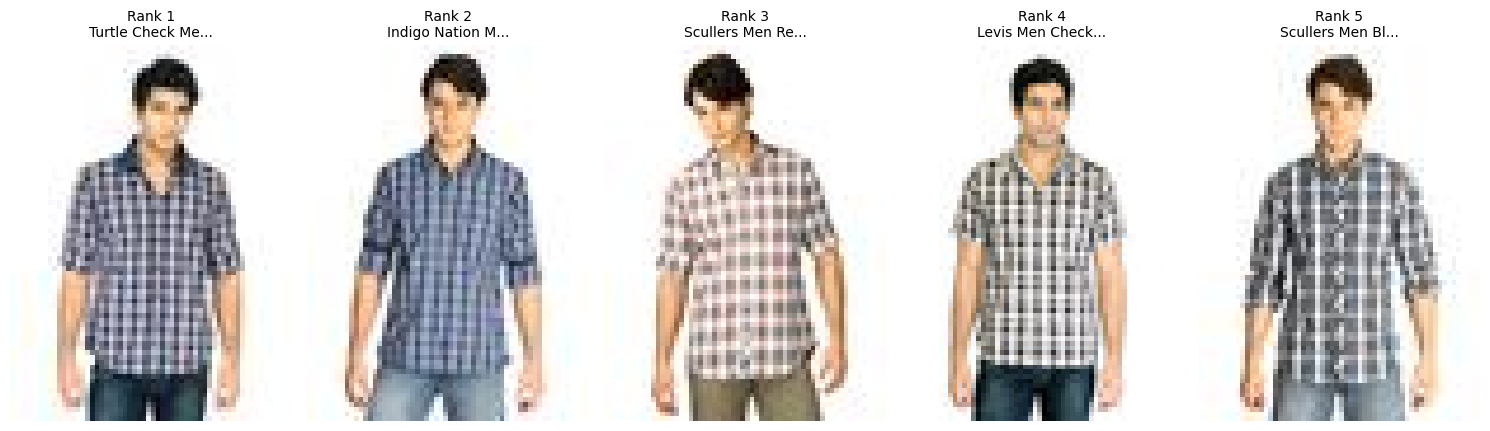

In [6]:
# 1. Choose a query image from our dataset (e.g., item index 0)
query_index = 0
query_id = valid_ids[query_index]
query_img_path = f"fashion_data/images/{query_id}.jpg"

# 2. Get the embedding of the query image
query_vector = embeddings_faiss[query_index].reshape(1, -1)

# 3. Search for top 5 similar items using FAISS
k = 5
distances, indices = index.search(query_vector, k)

# 4. Display query image alongside the top recommendations
fig, axes = plt.subplots(1, k, figsize=(15, 5))

for i in range(k):
    matched_idx = indices[0][i]
    matched_id = valid_ids[matched_idx]

    img = Image.open(f"fashion_data/images/{matched_id}.jpg")
    axes[i].imshow(img)

    # Get product title
    title = df[df['id'] == matched_id]['productDisplayName'].values[0]
    axes[i].set_title(f"Rank {i+1}\n{title[:15]}...", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# 1. Install FastAPI and Uvicorn server tools
!pip install fastapi uvicorn python-multipart nest_asyncio -q

import nest_asyncio
import uvicorn
from fastapi import FastAPI, UploadFile, File
import io

# Allow nested loops (needed for running FastAPI inside Colab)
nest_asyncio.apply()

# 2. Create the FastAPI app
app = FastAPI(title="Visual Search API")

@app.get("/")
def home():
    return {"message": "Visual Search API is live!"}

@app.post("/recommend/")
async def recommend(file: UploadFile = File(...)):
    # Read uploaded image
    contents = await file.read()
    img = Image.open(io.BytesIO(contents)).convert('RGB')

    # Process image into embedding
    tensor_img = transform(img).unsqueeze(0).cuda()
    with torch.no_grad():
        embedding = model(tensor_img).squeeze().cpu().numpy().astype('float32').reshape(1, -1)

    # Search FAISS index for top 5 matches
    distances, indices = index.search(embedding, 5)

    # Gather product recommendations
    results = []
    for idx in indices[0]:
        matched_id = valid_ids[idx]
        product_info = df[df['id'] == matched_id].to_dict('records')[0]
        results.append({
            "id": int(product_info['id']),
            "name": str(product_info['productDisplayName']),
            "category": str(product_info['masterCategory']),
            "subCategory": str(product_info['subCategory'])
        })

    return {"recommended_products": results}

print("FastAPI application defined successfully!")

FastAPI application defined successfully!


In [8]:
import threading
import requests

# 1. Function to run the FastAPI server on port 8000
def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

# Start server in a background thread
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

import time
time.sleep(2)  # Give server a moment to launch

# 2. Test the endpoint by sending a product image
test_image_path = f"fashion_data/images/{valid_ids[10]}.jpg"

with open(test_image_path, "rb") as img_file:
    response = requests.post(
        "http://127.0.0.1:8000/recommend/",
        files={"file": ("test.jpg", img_file, "image/jpeg")}
    )

# 3. Print the JSON response returned by your API
print("API Response Status Code:", response.status_code)
print("\nRecommended Products from API:")
import json
print(json.dumps(response.json(), indent=2))

INFO:     Started server process [1501]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:56732 - "POST /recommend/ HTTP/1.1" 200 OK
API Response Status Code: 200

Recommended Products from API:
{
  "recommended_products": [
    {
      "id": 9204,
      "name": "Puma Men Future Cat Remix SF Black Casual Shoes",
      "category": "Footwear",
      "subCategory": "Shoes"
    },
    {
      "id": 44941,
      "name": "Franco Leone Men Formal Shoes",
      "category": "Footwear",
      "subCategory": "Shoes"
    },
    {
      "id": 45603,
      "name": "Arrow Men Black Formal Shoes",
      "category": "Footwear",
      "subCategory": "Shoes"
    },
    {
      "id": 14431,
      "name": "Enroute Women Casual Black Flats",
      "category": "Footwear",
      "subCategory": "Shoes"
    },
    {
      "id": 9036,
      "name": "Buckaroo Men Flores Black Formal Shoes",
      "category": "Footwear",
      "subCategory": "Shoes"
    }
  ]
}


In [9]:
# 1. Install Gradio
!pip install gradio -q

import gradio as gr

# 2. Define the core visual recommendation function for the UI
def recommend_products(uploaded_image):
    if uploaded_image is None:
        return []

    # Convert uploaded image to PIL Image format
    img = Image.fromarray(uploaded_image).convert('RGB')

    # Extract features using our PyTorch ResNet model
    tensor_img = transform(img).unsqueeze(0).cuda()
    with torch.no_grad():
        embedding = model(tensor_img).squeeze().cpu().numpy().astype('float32').reshape(1, -1)

    # Search FAISS index for top 5 visual matches
    distances, indices = index.search(embedding, 5)

    # Format matched images for Gradio's gallery view
    recommended_gallery = []
    for idx in indices[0]:
        matched_id = valid_ids[idx]
        matched_img = Image.open(f"fashion_data/images/{matched_id}.jpg")
        title = df[df['id'] == matched_id]['productDisplayName'].values[0]
        recommended_gallery.append((matched_img, title))

    return recommended_gallery

# 3. Create the Gradio Drag-and-Drop Interface
interface = gr.Interface(
    fn=recommend_products,
    inputs=gr.Image(label="Drag & Drop or Upload Product Image Here"),
    outputs=gr.Gallery(label="Top 5 Visually Similar Products", columns=5, height="auto"),
    title="🛍️ Smart E-Commerce Visual Product Search",
    description="Upload an image of a shirt, shoe, or accessory to discover visually similar recommendations!"
)

# 4. Launch the web interface (share=True creates a public URL)
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b518f7d850c7fe9e37.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
